In [1]:
# ================================
# STEP 0: SETUP & CONFIGURATION
# ================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_colwidth', None)
sns.set(style="whitegrid")

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("✅ Setup complete")

✅ Setup complete


In [7]:
# ================================
# STEP 1: LOAD DATASET (AG NEWS)
# ================================
from datasets import load_dataset
import pandas as pd

try:
    # Load dataset
    # dataset = load_dataset("ag_news")

    # Convert to pandas
    train_df = dataset["train"].to_pandas()
    test_df = dataset["test"].to_pandas()

    # Combine (for EDA)
    df = pd.concat([train_df, test_df], ignore_index=True)

    print("✅ AG News dataset loaded successfully")
    print(f"Shape: {df.shape}")

    print("\nSample data:")
    display(df.head())

except Exception as e:
    print("❌ Error loading dataset:", e)

✅ AG News dataset loaded successfully
Shape: (127600, 2)

Sample data:


,text,label
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",2
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",2
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,2
3,"Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",2
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.",2


In [8]:
# ================================
# STEP 1.1: MAP LABELS TO NAMES
# ================================

label_map = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

df["category"] = df["label"].map(label_map)
df.rename(columns={"text": "text"}, inplace=True)

print("✅ Labels mapped")
df[["text", "category"]].head()

✅ Labels mapped


,text,category
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",Business
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,Business
3,"Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",Business
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.",Business


In [9]:
# ================================
# STEP 1.2: FINAL COLUMN FORMAT
# ================================

df = df[["text", "category"]]

print("Final columns:", df.columns)
print(df.head())

Final columns: Index(['text', 'category'], dtype='object')
                                                                                                                                                                                                                                                                         text  \
0                                                                                                                            Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.   
1  Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.   
2                                    Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus w

In [10]:
# ================================
# STEP 2: Basic Inspection
# ================================

print("🔹 First 5 rows:")
display(df.head())

print("\n🔹 Dataset Info:")
print(df.info())

print("\n🔹 Missing Values:")
print(df.isnull().sum())


🔹 First 5 rows:


,text,category
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",Business
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,Business
3,"Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",Business
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.",Business



🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   text      127600 non-null  object
 1   category  127600 non-null  object
dtypes: object(2)
memory usage: 1.9+ MB
None

🔹 Missing Values:
text        0
category    0
dtype: int64


In [11]:
# ================================
# STEP 3: DATA CLEANING
# ================================

# Drop duplicates
initial_shape = df.shape
df.drop_duplicates(inplace=True)

print(f"Removed {initial_shape[0] - df.shape[0]} duplicate rows")

# Drop missing values (adjust if needed)
df.dropna(inplace=True)

print(f"Shape after cleaning: {df.shape}")

Removed 0 duplicate rows
Shape after cleaning: (127600, 2)


category
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64


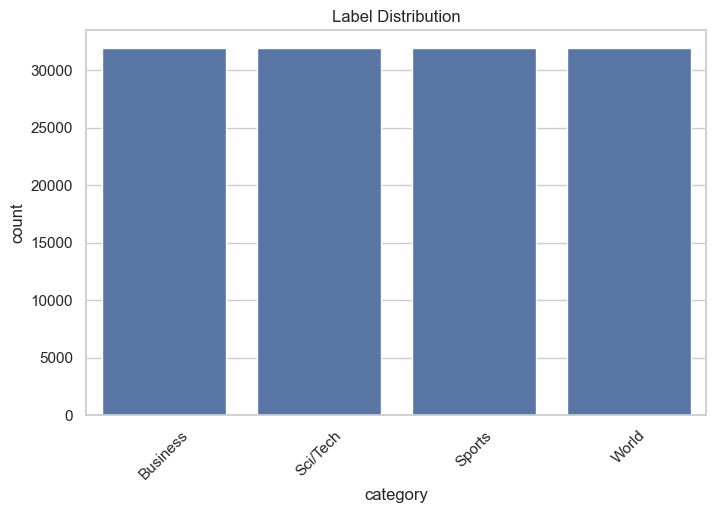

In [12]:
# ================================
# STEP 4: LABEL DISTRIBUTION
# ================================

label_col = "category"  # change if needed

print(df[label_col].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x=label_col, order=df[label_col].value_counts().index)
plt.xticks(rotation=45)
plt.title("Label Distribution")
plt.show()

count    127600.000000
mean         37.840000
std          10.087912
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64


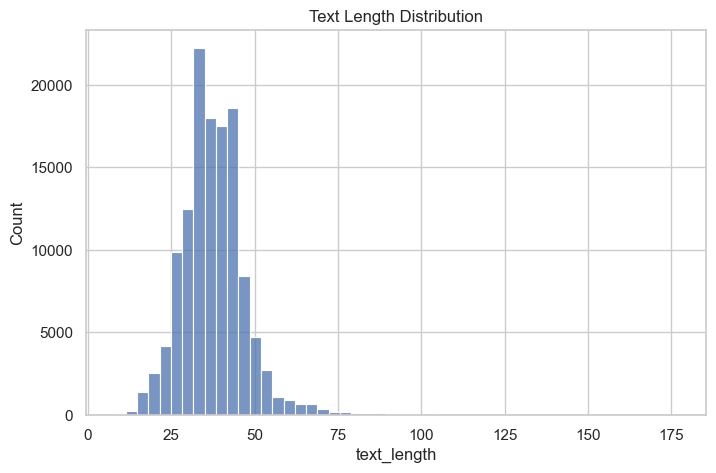

In [13]:
# ================================
# STEP 5: TEXT LENGTH ANALYSIS
# ================================

text_col = "text"  # change if needed

df["text_length"] = df[text_col].apply(lambda x: len(str(x).split()))

print(df["text_length"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [21]:
# ================================
# STEP 5.1: REMOVE EXTREME OUTLIERS
# Even though BERT truncates, extreme outliers add noise
# ================================

upper_limit = df["text_length"].quantile(0.99)

initial_size = df.shape[0]

df = df[df["text_length"] <= upper_limit]

print(f"Removed {initial_size - df.shape[0]} outliers")
print(f"New shape: {df.shape}")

Removed 1201 outliers
New shape: (126399, 4)


In [22]:
# ================================
# STEP 5.2: REMOVE VERY SHORT TEXT
# ================================

df = df[df["text_length"] > 3]

In [23]:
# ================================
# STEP 6: TEXT CLEANING
# ================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"\n", "", text)            # remove newlines
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df["clean_text"] = df[text_col].apply(clean_text)

print("✅ Text cleaning completed")

✅ Text cleaning completed


In [24]:
# ================================
# STEP 7: VOCABULARY ANALYSIS
# ================================

from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words)

print("Top 20 words:")
print(word_freq.most_common(20))

Top 20 words:
[('the', 210641), ('to', 123728), ('a', 111529), ('of', 101512), ('in', 99012), ('and', 70678), ('on', 58809), ('for', 52143), ('-', 40561), ('#39;s', 33130), ('that', 28379), ('with', 27710), ('as', 26100), ('at', 25852), ('its', 23042), ('is', 22548), ('new', 21935), ('by', 21532), ('has', 19773), ('it', 19363)]


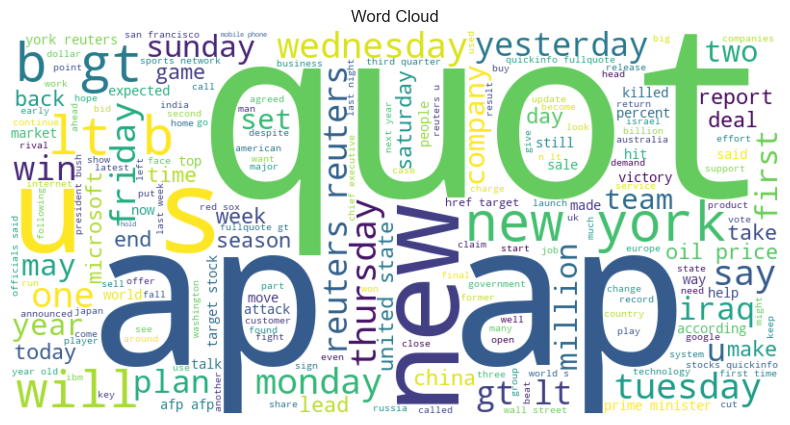

In [25]:
# ================================
# STEP 8: WORD CLOUD
# ================================
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white')\
            .generate(" ".join(df["clean_text"]))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [19]:
# ================================
# STEP 9: TRAIN-TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df[label_col],
    random_state=SEED
)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (102080, 4)
Test shape: (25520, 4)


In [26]:
# ================================
# STEP 10: SAVE PROCESSED DATA
# ================================

os.makedirs("processed", exist_ok=True)

train_df.to_csv("processed/train.csv", index=False)
test_df.to_csv("processed/test.csv", index=False)

print("✅ Processed data saved")

✅ Processed data saved
